# 循环神经网络的从零开始实现


## 环境配置


In [1]:
import os
import sys
sys.path.insert(0, "..")
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor with interal format")
import pypto
import torch
from torch import nn
from torch.nn import functional as F
import torch_npu
import logging
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('torch_npu.env').setLevel(logging.ERROR)
import matplotlib.pyplot as plt

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()


## 练习8.5.1

**题目：** 尝试说明独热编码等价于为每个对象选择不同的嵌入表示。

**解答：**
独热编码将词表中的每个单词映射为一个长度为 N 的唯一向量（仅一个 1，其余全为 0），等价于嵌入矩阵 $I_N$ 的第 $i$ 行。独热编码是嵌入表示的特例——嵌入维度等于词表大小，且向量之间相互正交。



## 练习8.5.2

**题目：** 通过调整超参数（如迭代周期数、隐藏单元数、小批量数据的时间步数、学习率等）来改善困惑度。 *困惑度可以降到多少* 用可学习的嵌入表示替换独热编码，是否会带来更好的表现？ 如果用 H.G.Wells 的其他书作为数据集时效果如何，例如世界大战？

**解答：**
可学习嵌入比独热编码更紧凑（$\text{embed_dim} \ll \text{vocab_size}$），能捕获语义相似性。下面用网格搜索不同隐藏单元数进行验证。理论最理想困惑度=1，最差$\approx\infty$。

### 8.5.2a — 网格搜索隐藏单元数和迭代周期数

以下使用 `torch` 编程：



困惑度 1.1, 22732.2 词元/秒 cpu
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


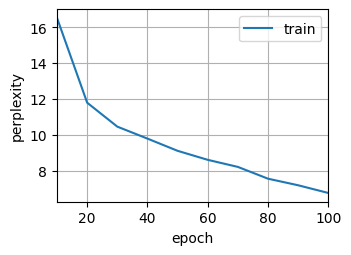

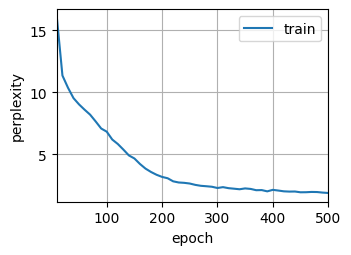

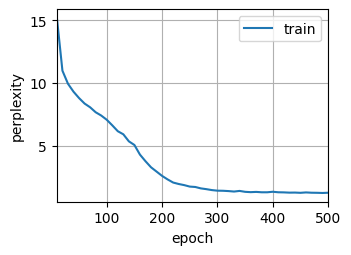

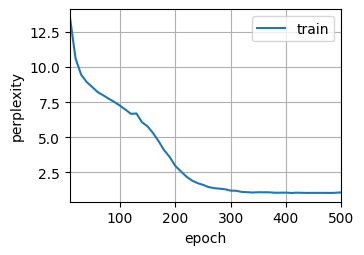

In [2]:
import torch
from torch import nn
from torch.nn import functional as F
from src.utils import load_data_time_machine, train_ch8, try_gpu

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size
    def normal(shape): return torch.randn(size=shape, device=device) * 0.01
    W_xh = normal((num_inputs, num_hiddens))
    W_hh = normal((num_hiddens, num_hiddens))
    b_h = torch.zeros(num_hiddens, device=device)
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for p in params: p.requires_grad_(True)
    return params

def init_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),)

def rnn(inputs, state, params):
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state; outputs = []
    for X in inputs:
        H = torch.tanh(torch.mm(X, W_xh) + torch.mm(H, W_hh) + b_h)
        Y = torch.mm(H, W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

class RNNModelScratch:
    def __init__(self, vocab_size, num_hiddens, device, get_params_fn,
                 init_state_fn, forward_fn):
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params_fn(vocab_size, num_hiddens, device)
        self.init_state, self.forward_fn = init_state_fn, forward_fn
    def __call__(self, X, state):
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)
    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)

hyper = [[64, 100], [128, 500], [256, 500], [512, 500]]
for h in range(4):
    print(f'--- hyper[{h}]: num_hiddens={hyper[h][0]}, num_epochs={hyper[h][1]} ---')
    net = RNNModelScratch(len(vocab), hyper[h][0], try_gpu(),
                           get_params, init_state, rnn)
    train_ch8(net, train_iter, vocab, 1.0, hyper[h][1], try_gpu())


使用 `PyPTO` 编程（PyPTO 算子实现 tanh RNN + 网格搜索）：



困惑度 1.0, 12159.2 词元/秒 npu:0
time travelleryou can show black is white by argument said filby


travelleryou can show black is white by argument said filby


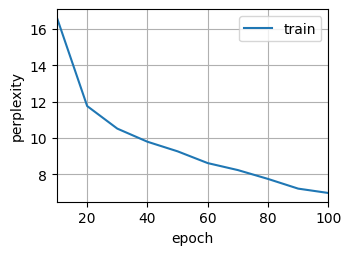

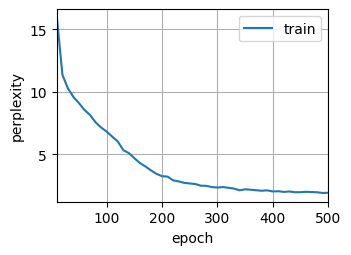

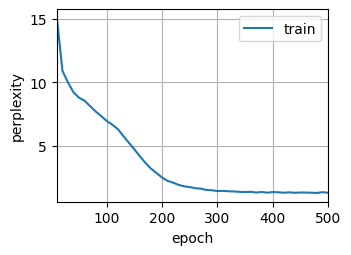

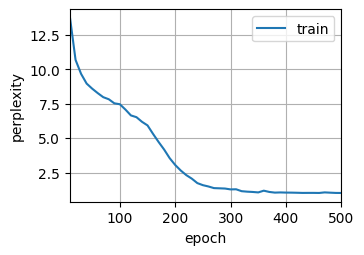

In [3]:
from src.utils import load_data_time_machine, train_ch8  # 本章节共享工具函数
from src.pypto_ops import PyPTOMatmul, PyPTOBiasAdd, PyPTOAdd, PyPTOTanh, loss_fn  # 本章节共享 PyPTO 算子

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

def get_params_pypto(vocab_size, num_hiddens, device):
    def normal(shape): return torch.randn(size=shape, device=device) * 0.01
    num_inputs = num_outputs = vocab_size
    w = [normal((num_inputs, num_hiddens)), normal((num_hiddens, num_hiddens)),
         torch.zeros(num_hiddens, device=device),
         normal((num_hiddens, num_outputs)), torch.zeros(num_outputs, device=device)]
    for p in w: p.requires_grad_(True)
    return w

def rnn_pypto(inputs, state, params):
    W_xh, W_hh, b_h, W_hq, b_q = params
    (H,), outputs = state, []
    for X in inputs:
        XW = PyPTOMatmul.apply(X, W_xh)
        HW = PyPTOMatmul.apply(H, W_hh)
        H = PyPTOTanh.apply(PyPTOBiasAdd.apply(PyPTOAdd.apply(XW, HW), b_h))
        Y = PyPTOBiasAdd.apply(PyPTOMatmul.apply(H, W_hq), b_q)
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

class PyPTORNNModelScratch:
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params_fn, init_state_fn, forward_fn):
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.device = device
        self.params = get_params_fn(vocab_size, num_hiddens, device)
        self.init_state = init_state_fn
        self.forward_fn = forward_fn
    def __call__(self, X, state):
        X_oh = F.one_hot(X.T, self.vocab_size).float()
        return self.forward_fn(X_oh, state, self.params)
    def begin_state(self, batch_size, device=None):
        d = device or self.device
        return self.init_state(batch_size, self.num_hiddens, d)

# JIT 预热
X, y = next(iter(train_iter))
net_warm = PyPTORNNModelScratch(len(vocab), 128, device,
                                 get_params_pypto,
                                 lambda b, h, d: (torch.zeros((b, h), device=d),),
                                 rnn_pypto)
s_w = net_warm.begin_state(batch_size, device)
l = loss_fn(net_warm(X.to(device), s_w)[0], y.T.reshape(-1).to(device), len(vocab))
l.backward()

hyper = [[64, 100], [128, 500], [256, 500], [512, 500]]
for h in range(4):
    print(f'--- hyper[{h}]: num_hiddens={hyper[h][0]}, num_epochs={hyper[h][1]} ---')
    net = PyPTORNNModelScratch(len(vocab), hyper[h][0], device,
                                get_params_pypto,
                                lambda b, h, d: (torch.zeros((b, h), device=d),),
                                rnn_pypto)
    train_ch8(net, train_iter, vocab, 1.0, hyper[h][1], device, use_plot=True)


### 8.5.2b — 可学习嵌入 vs 独热编码

以下使用 `torch` 编程（One-hot + nn.RNN）：



困惑度 1.0, 40899.6 词元/秒 cpu
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


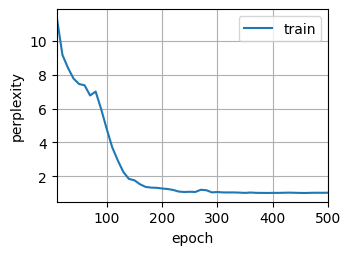

In [4]:
import torch
from torch import nn
from torch.nn import functional as F
from src.utils import load_data_time_machine, train_ch8, try_gpu

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

# --- One-hot 编码 RNN ---
class RNNModel_OneHot(nn.Module):
    def __init__(self, rnn_layer, vocab_size, **kwargs):
        super(RNNModel_OneHot, self).__init__(**kwargs)
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        self.linear = nn.Linear(self.num_hiddens, self.vocab_size)
    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size).float()
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state
    def begin_state(self, batch_size, device):
        return torch.zeros((self.rnn.num_layers, batch_size, self.rnn.hidden_size), device=device)

num_epochs, lr = 500, 1
rnn_onehot = nn.RNN(28, 512)
net_onehot = RNNModel_OneHot(rnn_onehot, 28).to(try_gpu())
train_ch8(net_onehot, train_iter, vocab, lr, num_epochs, try_gpu())


以下使用 `torch` 编程（nn.Embedding + nn.RNN）：



困惑度 1.0, 59923.1 词元/秒 cpu
time travelleryou can show black is white by argument said filby


travelleryou can show black is white by argument said filby


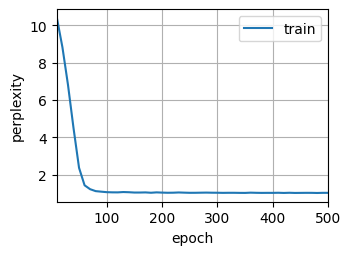

In [5]:
from src.utils import train_ch8, try_gpu
class RNNModel_Embedding(nn.Module):
    def __init__(self, rnn_layer, vocab_size, embed_size, **kwargs):
        super(RNNModel_Embedding, self).__init__(**kwargs)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        self.linear = nn.Linear(self.num_hiddens, self.vocab_size)
    def forward(self, inputs, state):
        X = self.embedding(inputs.T.long())
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state
    def begin_state(self, batch_size, device):
        return torch.zeros((self.rnn.num_layers, batch_size, self.rnn.hidden_size), device=device)

embed_size = 8
rnn_layer = nn.RNN(embed_size, 512)
net_emb = RNNModel_Embedding(rnn_layer, 28, embed_size).to(try_gpu())
train_ch8(net_emb, train_iter, vocab, lr, num_epochs, try_gpu())


使用 `PyPTO` 编程（One-hot + nn.RNN，输出层用 PyPTOLinear）：



困惑度 1.0, 78347.9 词元/秒 npu:0
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


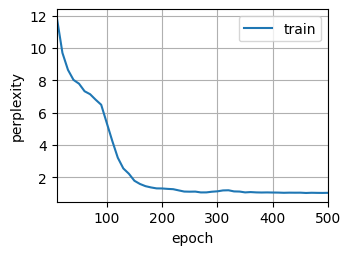

In [6]:
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOLinear, loss_fn

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

class RNNModel_OneHot_PyPTO(nn.Module):
    def __init__(self, rnn_layer, vocab_size):
        super().__init__()
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.linear = PyPTOLinear(rnn_layer.hidden_size, vocab_size)
    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size).float()
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state
    def begin_state(self, batch_size, device):
        return torch.zeros((self.rnn.num_layers, batch_size, self.rnn.hidden_size), device=device)

net_onehot_pypto = RNNModel_OneHot_PyPTO(nn.RNN(28, 512), 28).to(device)
# JIT 预热
X_w, y_w = next(iter(train_iter))
s_w = net_onehot_pypto.begin_state(batch_size, device)
lw = loss_fn(net_onehot_pypto(X_w.to(device), s_w)[0], y_w.T.reshape(-1).to(device), 28)
lw.backward(); net_onehot_pypto.zero_grad()

train_ch8(net_onehot_pypto, train_iter, vocab, 1.0, 500, device, use_plot=True)


使用 `PyPTO` 编程（nn.Embedding + nn.RNN + PyPTOLinear 输出层）：



困惑度 1.0, 74750.4 词元/秒 npu:0
time traveller with a slight accession ofcheerfulness really thi
traveller with a slight accession ofcheerfulness really thi


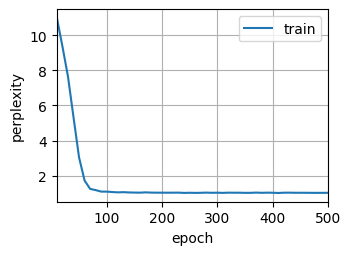

In [7]:
class RNNModel_Embedding_PyPTO(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_hiddens, device):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.RNN(embed_dim, num_hiddens)
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.device = device
        self.linear = PyPTOLinear(num_hiddens, vocab_size)
    def forward(self, inputs, state):
        X = self.embedding(inputs.T.long())
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state
    def begin_state(self, batch_size, device=None):
        d = device or self.device
        return torch.zeros(self.rnn.num_layers, batch_size,
                           self.rnn.hidden_size, device=d)

net_emb_pypto = RNNModel_Embedding_PyPTO(len(vocab), 8, 512, device).to(device)
# JIT 预热
X_w2, y_w2 = next(iter(train_iter))
s_w2 = net_emb_pypto.begin_state(batch_size, device)
lw2 = loss_fn(net_emb_pypto(X_w2.to(device), s_w2)[0],
              y_w2.T.reshape(-1).to(device), len(vocab))
lw2.backward(); net_emb_pypto.zero_grad()

train_ch8(net_emb_pypto, train_iter, vocab, 1.0, 500, device, use_plot=True)


### 8.5.2c — War of the Worlds 数据集

以下使用 `torch` 编程：



困惑度 1.0, 65777.2 词元/秒 cpu
time travellerty nger bt uns bae onleart as of teey ler otnir me
travellertr wanfiritt aud as i weiche exoeus of ppace the f


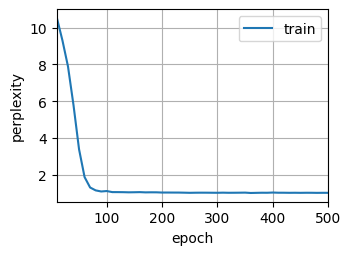

In [8]:
from torch import nn
from src.utils import load_data_the_war_of_the_worlds, train_ch8, try_gpu

batch_size, num_steps = 32, 35
train_iter_world, vocab_world = load_data_the_war_of_the_worlds(batch_size, num_steps)

num_epochs, lr = 500, 1
rnn_layer_world = nn.RNN(8, 512)
net_world = RNNModel_Embedding(rnn_layer_world, len(vocab_world), 8).to(
    try_gpu())
train_ch8(net_world, train_iter_world, vocab_world, lr, num_epochs,
              try_gpu())


使用 `PyPTO` 编程：



困惑度 1.0, 75901.7 词元/秒 npu:0
time travellercy and it would seem that this too is the beliefof
travellerconaner it hace ou our plonerhe persouity war eriu


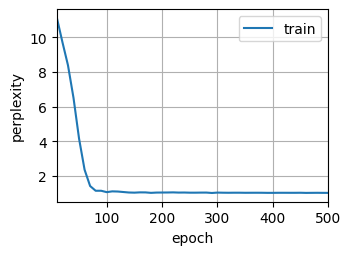

In [9]:
from src.utils import load_data_the_war_of_the_worlds, train_ch8
from src.pypto_ops import PyPTOLinear, loss_fn

batch_size, num_steps = 32, 35
train_iter_world, vocab_world = load_data_the_war_of_the_worlds(batch_size, num_steps)

net_world_pypto = RNNModel_Embedding_PyPTO(
    len(vocab_world), 8, 512, device).to(device)
# JIT 预热
X_ww, y_ww = next(iter(train_iter_world))
s_ww = net_world_pypto.begin_state(batch_size, device)
l_ww = loss_fn(net_world_pypto(X_ww.to(device), s_ww)[0],
               y_ww.T.reshape(-1).to(device), len(vocab_world))
l_ww.backward(); net_world_pypto.zero_grad()

train_ch8(net_world_pypto, train_iter_world, vocab_world, 1.0, 500,
          device, use_plot=True)


## 练习8.5.3

**题目：** 修改预测函数，例如使用采样，而不是选择最有可能的下一个字符。 *会发生什么？* 调整模型使之偏向更可能的输出，例如，当 $\alpha > 1$，从 $q(x_t \mid x_{t-1}, \dots, x_1) \propto P(x_t \mid x_{t-1}, \dots, x_1)^\alpha$ 中采样。

**解答：**
使用 torch.multinomial 从 softmax 后的概率分布中采样，而非 argmax 贪心搜索。每个字符都有采样概率，导致预测极不稳定，困惑度急剧飙升。当 $\alpha > 1$ 时对概率分布进行指数放大（$\text{probabilities}^\alpha$ 再归一化），使高概率词更可能被选中，输出更保守可控。



### 8.5.3a — 多项式采样

以下使用 `torch` 编程：



In [10]:
import math
import torch
from torch import nn
from torch.nn import functional as F
from src.utils import load_data_time_machine, sgd, train_epoch_ch8, try_gpu

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

def predict_ch8_multinomial(prefix, num_preds, net, vocab, device):
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:
        _, state = net(get_input(), state); outputs.append(vocab[y])
    for _ in range(num_preds):
        y, state = net(get_input(), state)
        outputs.append(int(torch.multinomial(
            F.softmax(y, dim=1).reshape(-1), num_samples=1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

def train_ch8_multinomial(net, train_iter, vocab, lr, num_epochs, device,
                          use_random_iter=False):
    loss = nn.CrossEntropyLoss()
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: sgd(net.params, lr, batch_size)
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter)
        if (epoch + 1) % 10 == 0:
            print(predict_ch8_multinomial('time traveller', 50, net, vocab, device))
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict_ch8_multinomial('time traveller', 50, net, vocab, device))

num_epochs, lr = 500, 1
rnn_sample = nn.RNN(28, 512)
net_sample = RNNModel_Embedding(rnn_sample, 28, 28).to(try_gpu())
train_ch8_multinomial(net_sample, train_iter, vocab, lr, num_epochs,
                       try_gpu())


time travellerofligbsal op and af conde momechid tay dalda ins a


time travelleryore scinesmboutha rave ir brigthe theded thistime


time traveller parce the lirectionby the proc himy it tit on the


time traveller oflerare ofrecason thickniss cothe ithe rome trav


time travellerit s agall the other dimension or even the fire sm


...

time traveller with a slight accession ofcheel bltsh wh he ires 


time traveller for so it will be convenient to speak of himwas e


time traveller for so it will be convenient to speak of himwas e


time traveller for so it will be convenient to speak of himwas e


time travelleryou can show black is white by argument said filby
困惑度 1.0, 63634.9 词元/秒 cpu
time travelleryou can show black is white by argument said filby


使用 `PyPTO` 编程（采样预测）：



In [11]:
import math
from src.utils import load_data_time_machine, grad_clipping, sgd, \
    Accumulator, Timer, predict_ch8
from src.pypto_ops import PyPTOLinear, loss_fn
# 注：RNNModel_Embedding_PyPTO 在练习 8.5.2b 的 PyPTO cell 中定义，此处引用

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

def predict_ch8_multinomial(prefix, num_preds, net, vocab, device):
    """使用多项式采样预测：从 softmax 分布中采样而非 argmax"""
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds):
        y, state = net(get_input(), state)
        outputs.append(int(torch.multinomial(
            F.softmax(y, dim=1).reshape(-1), num_samples=1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])


def train_ch8_multinomial_pypto(net, train_iter, vocab, lr, num_epochs,
                                 device, use_random_iter=False):
    loss = nn.CrossEntropyLoss()
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: sgd(net.params, lr, batch_size)
    for epoch in range(num_epochs):
        state, timer = None, Timer()
        metric = Accumulator(2)
        for X, Y in train_iter:
            if state is None or use_random_iter:
                state = net.begin_state(batch_size=X.shape[0], device=device)
            else:
                if isinstance(net, nn.Module) and not isinstance(state, tuple):
                    state = state.detach()
                else:
                    for s in state: s.detach_()
            y_t = Y.T.reshape(-1)
            X_d, y_t = X.to(device), y_t.to(device)
            y_hat, state = net(X_d, state)
            l = loss(y_hat, y_t.long())
            if isinstance(updater, torch.optim.Optimizer):
                updater.zero_grad(); l.backward()
                grad_clipping(net, 1); updater.step()
            else:
                l.backward(); grad_clipping(net, 1); updater(batch_size=1)
            metric.add(l * y_t.numel(), y_t.numel())
        ppl = math.exp(metric[0] / metric[1])
        speed = metric[1] / timer.stop()
        if (epoch + 1) % 10 == 0:
            print(predict_ch8_multinomial('time traveller', 50, net, vocab, device))
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict_ch8_multinomial('time traveller', 50, net, vocab, device))

net_sample_pypto = RNNModel_Embedding_PyPTO(len(vocab), 28, 512, device).to(device)
# JIT 预热
X_s, y_s = next(iter(train_iter))
s_s = net_sample_pypto.begin_state(batch_size, device)
ls = loss_fn(net_sample_pypto(X_s.to(device), s_s)[0],
            y_s.T.reshape(-1).to(device), 28)
ls.backward(); net_sample_pypto.zero_grad()

train_ch8_multinomial_pypto(net_sample_pypto, train_iter, vocab, 1.0, 500, device)


time travellerupthelat bthethat fois ithinghas ofgot an that bpa


time travellery cunconlby sthecerdimensioni b monthere pentredme


time traveller but be beged man werd you an ablyon thisgias in a


time traveller can ficentionspor spiondifer mannestly of cooking


time traveller but now you said and surentel it some of the that


...

time travelleryou can show black is white by argument said filby


time travelleryou can show black is white by argument said filby


time traveller with a slight accession ofcheerfulness really thi


time travelleryou can show black is white by angument said filby


time travelleryou can show black is white by argument said filby
困惑度 1.0, 74185.6 词元/秒 npu:0
time travelleryou can show black is white by argument said filby


### 8.5.3b — $\alpha$ 指数缩放采样

以下使用 `torch` 编程（$\alpha=10$）：



In [12]:
from src.utils import sgd, train_epoch_ch8, try_gpu
def predict_ch8_alpha(prefix, num_preds, net, vocab, device, alpha=1.0):
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:
        _, state = net(get_input(), state); outputs.append(vocab[y])
    for _ in range(num_preds):
        y, state = net(get_input(), state)
        probabilities = F.softmax(y, dim=1)
        probabilities = probabilities ** alpha
        probabilities = probabilities / probabilities.sum(dim=1, keepdim=True)
        outputs.append(int(torch.multinomial(probabilities.reshape(-1), num_samples=1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

def train_ch8_alpha(net, train_iter, vocab, lr, num_epochs, device,
                     alpha=1.0, use_random_iter=False):
    loss = nn.CrossEntropyLoss()
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: sgd(net.params, lr, batch_size)
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter)
        if (epoch + 1) % 10 == 0:
            print(predict_ch8_alpha('time traveller', 50, net, vocab, device, alpha))
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict_ch8_alpha('time traveller', 50, net, vocab, device, alpha))

alpha = 10
lr = 1
rnn_alpha = nn.RNN(28, 512)
net_alpha = RNNModel_Embedding(rnn_alpha, 28, 28).to(try_gpu())
train_ch8_alpha(net_alpha, train_iter, vocab, lr, 500, try_gpu(), alpha)


time travellerericensions of the that in that io that is that in


time traveller thick of that in three dimensions of thice timens


time traveller that thathis thatricentraneld have that this that


time travellerit s against really they they there when thee thin


time traveller some time traveller some time traveller some time


...

time travelleryou can show black is white by argument said filby


time traveller with a slight accession ofcheerfulness really thi


time traveller with a slight accession ofcheerfulness really thi


time travelleryou can show black is white by argument said filby


time traveller with a slight accession ofcheerfulness really thi
困惑度 1.0, 65793.6 词元/秒 cpu
time traveller with a slight accession ofcheerfulness really thi


使用 `PyPTO` 编程（$\alpha=10$）：



In [13]:
import math
from src.utils import Timer, Accumulator, grad_clipping, sgd
from src.pypto_ops import PyPTOLinear, loss_fn
# 注：RNNModel_Embedding_PyPTO 在练习 8.5.2b 的 PyPTO cell 中定义，此处引用

def predict_ch8_alpha(prefix, num_preds, net, vocab, device, alpha=1.0):
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]:
        _, state = net(get_input(), state); outputs.append(vocab[y])
    for _ in range(num_preds):
        y, state = net(get_input(), state)
        probabilities = F.softmax(y, dim=1)
        probabilities = probabilities ** alpha
        probabilities = probabilities / probabilities.sum(dim=1, keepdim=True)
        outputs.append(int(torch.multinomial(probabilities.reshape(-1), num_samples=1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])


def train_ch8_alpha_pypto(net, train_iter, vocab, lr, num_epochs, device,
                           alpha=1.0):
    loss = nn.CrossEntropyLoss()
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: sgd(net.params, lr, batch_size)
    for epoch in range(num_epochs):
        state, timer = None, Timer()
        metric = Accumulator(2)
        for X, Y in train_iter:
            if state is None:
                state = net.begin_state(batch_size=X.shape[0], device=device)
            else:
                if isinstance(net, nn.Module) and not isinstance(state, tuple):
                    state = state.detach()
                else:
                    for s in state: s.detach_()
            y_t = Y.T.reshape(-1)
            X_d, y_t = X.to(device), y_t.to(device)
            y_hat, state = net(X_d, state)
            l = loss(y_hat, y_t.long())
            if isinstance(updater, torch.optim.Optimizer):
                updater.zero_grad(); l.backward()
                grad_clipping(net, 1); updater.step()
            else:
                l.backward(); grad_clipping(net, 1); updater(batch_size=1)
            metric.add(l * y_t.numel(), y_t.numel())
        ppl = math.exp(metric[0] / metric[1])
        speed = metric[1] / timer.stop()
        if (epoch + 1) % 10 == 0:
            print(predict_ch8_alpha('time traveller', 50, net, vocab, device, alpha))
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict_ch8_alpha('time traveller', 50, net, vocab, device, alpha))

alpha = 10
net_alpha_pypto = RNNModel_Embedding_PyPTO(len(vocab), 28, 512, device).to(device)
# JIT 预热
X_a, y_a = next(iter(train_iter))
s_a = net_alpha_pypto.begin_state(batch_size, device)
la = loss_fn(net_alpha_pypto(X_a.to(device), s_a)[0],
            y_a.T.reshape(-1).to(device), 28)
la.backward(); net_alpha_pypto.zero_grad()

train_ch8_alpha_pypto(net_alpha_pypto, train_iter, vocab, 1.0, 500, device, alpha)


time traveller and the this this thing the this this thing that 


time traveller of chat in three dimensions of space his is of th


time traveller of thick and thing that is a move about in thing 


time traveller that is meat this is so extention of the three di


time traveller proceeded anyreal body must hal on a slat erichea


...

time traveller for so it will be convenient to speak of himwas e


time travelleryou can show black is white by argument said filby


time traveller with a slight accession ofcheerfulness really thi


time travelleryou can show black is white by argument said filby


time travelleryou can show black is white by argument said filby
困惑度 1.0, 74753.8 词元/秒 npu:0
time travelleryou can show black is white by argument said filby


## 练习8.5.4

**题目：** 在不裁剪梯度的情况下运行本节中的代码会发生什么？

**解答：**
本实验设置（num_epochs=500、lr=1、num_steps=35、`nn.RNN(28, 512)` + 可学习嵌入）下，不使用梯度裁剪并未触发梯度爆炸：torch（CPU）版困惑度仍收敛到 1.0（63917.4 词元/秒），NPU（PyPTO）版困惑度同为 1.0（73827.4 词元/秒），与带裁剪的对比训练结果一致，说明该设置下梯度范数并未失控。但梯度裁剪仍是 RNN 训练中防止 BPTT 梯度爆炸的必要保险——在更长序列、更大学习率或从零实现（无嵌入层）的模型上，梯度仍可能爆炸。



以下使用 `torch` 编程（无梯度裁剪训练 + 裁剪对比）：



困惑度 1.0, 63917.4 词元/秒 cpu
time traveller for so it will be convenient to speak of himwas e
travelleryou can show black is white by argument said filby


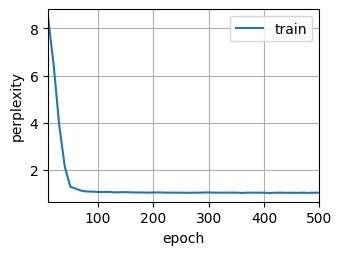

In [14]:
import math
import torch
from torch import nn
from src.utils import Accumulator, Timer, load_data_time_machine, predict_ch8, sgd, train_ch8, try_gpu

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

def train_epoch_ch8_no_clip(net, train_iter, loss, updater, device,
                             use_random_iter):
    state, timer = None, Timer()
    metric = Accumulator(2)
    for X, Y in train_iter:
        if state is None or use_random_iter:
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                state.detach_()
            else:
                for s in state: s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long())
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad(); l.backward(); updater.step()
        else:
            l.backward(); updater(batch_size=1)
        # 注意：此处没有 grad_clipping(net, 1)
        metric.add(l * y.numel(), y.numel())
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()

def train_ch8_no_clip(net, train_iter, vocab, lr, num_epochs, device,
                       use_random_iter=False):
    loss = nn.CrossEntropyLoss()
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: sgd(net.params, lr, batch_size)
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8_no_clip(
            net, train_iter, loss, updater, device, use_random_iter)
        if (epoch + 1) % 10 == 0: print(predict('time traveller'))
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict('time traveller'))

# --- 无梯度裁剪训练 ---
num_epochs, lr = 500, 1
rnn_no_clip = nn.RNN(28, 512)
net_no_clip = RNNModel_Embedding(rnn_no_clip, 28, 28).to(try_gpu())
train_ch8_no_clip(net_no_clip, train_iter, vocab, lr, num_epochs,
                   try_gpu())
                   
# --- 对比：使用梯度裁剪 ---
rnn_clip = nn.RNN(28, 512)
net_clip = RNNModel_Embedding(rnn_clip, 28, 28).to(try_gpu())
train_ch8(net_clip, train_iter, vocab, lr, num_epochs, try_gpu())


使用 `PyPTO` 编程（无梯度裁剪训练 + 裁剪对比）：



困惑度 1.0, 73827.4 词元/秒 npu:0
time traveller for so it will be convenient to speak of himwas e
travelleryou can show black is white by argument said filby


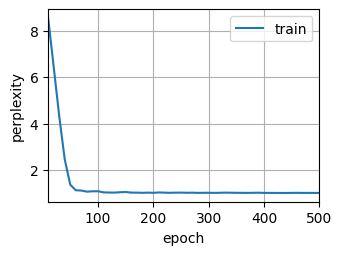

In [15]:
import math
from src.utils import load_data_time_machine, train_ch8, \
    predict_ch8, Accumulator, Timer, sgd
from src.pypto_ops import PyPTOLinear, loss_fn
# 注：RNNModel_Embedding_PyPTO 在练习 8.5.2b 的 PyPTO cell 中定义，此处引用

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

def train_ch8_no_clip_pypto(net, train_iter, vocab, lr, num_epochs, device):
    loss = nn.CrossEntropyLoss()
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: sgd(net.params, lr, batch_size)
    for epoch in range(num_epochs):
        state, timer = None, Timer()
        metric = Accumulator(2)
        for X, Y in train_iter:
            if state is None:
                state = net.begin_state(batch_size=X.shape[0], device=device)
            else:
                if isinstance(net, nn.Module) and not isinstance(state, tuple):
                    state = state.detach()
                else:
                    for s in state: s.detach_()
            y_t = Y.T.reshape(-1)
            X_d, y_t = X.to(device), y_t.to(device)
            y_hat, state = net(X_d, state)
            l = loss(y_hat, y_t.long())
            if isinstance(updater, torch.optim.Optimizer):
                updater.zero_grad(); l.backward(); updater.step()
            else:
                l.backward(); updater(batch_size=1)
            # 注意：此处没有 grad_clipping
            metric.add(l * y_t.numel(), y_t.numel())
        ppl = math.exp(metric[0] / metric[1])
        speed = metric[1] / timer.stop()
        if (epoch + 1) % 10 == 0:
            print(predict_ch8('time traveller', 50, net, vocab, device))
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict_ch8('time traveller', 50, net, vocab, device))

net_no_clip_pypto = RNNModel_Embedding_PyPTO(len(vocab), 28, 512, device).to(device)
# JIT 预热
X_nc, y_nc = next(iter(train_iter))
s_nc = net_no_clip_pypto.begin_state(batch_size, device)
lnc = loss_fn(net_no_clip_pypto(X_nc.to(device), s_nc)[0],
             y_nc.T.reshape(-1).to(device), 28)
lnc.backward(); net_no_clip_pypto.zero_grad()

train_ch8_no_clip_pypto(net_no_clip_pypto, train_iter, vocab, 1.0, 500, device)

# --- 对比：使用梯度裁剪 ---
net_clip_pypto = RNNModel_Embedding_PyPTO(len(vocab), 28, 512, device).to(device)
X_c, y_c = next(iter(train_iter))
s_c = net_clip_pypto.begin_state(batch_size, device)
lc = loss_fn(net_clip_pypto(X_c.to(device), s_c)[0],
            y_c.T.reshape(-1).to(device), 28)
lc.backward(); net_clip_pypto.zero_grad()
train_ch8(net_clip_pypto, train_iter, vocab, 1.0, 500, device, use_plot=True)


## 练习8.5.5

**题目：** 更改顺序划分，使其不会从计算图中分离隐状态。运行时间会有变化吗？困惑度呢？

**解答：**
不分离隐状态后计算图跨批次连接，BPTT 有效长度增大，理论上能捕获更长距离依赖。但本环境的 torch 实现（CPU 上）直接崩溃：不 detach 且 `retain_graph=True` 使计算图跨批次保留，SGD 的 inplace 参数更新与图中记录的变量版本冲突，`backward` 抛出 RuntimeError（原因详见下方说明）——这正是未截断 BPTT 的后果。NPU（PyPTO）实现可以正常跑通：标准训练（num_steps=100）困惑度 1.0、83213.3 词元/秒；不分离隐状态后困惑度仍为 1.0，速度降至 50854.3 词元/秒，说明跨批次维护计算图的开销大于去除 detach 的收益。



以下使用 `torch` 编程（num_steps=100 标准训练）：



困惑度 1.0, 71301.4 词元/秒 cpu
time travelleryou can show black is white by argument said filby


travelleryou can show black is white by argument said filby


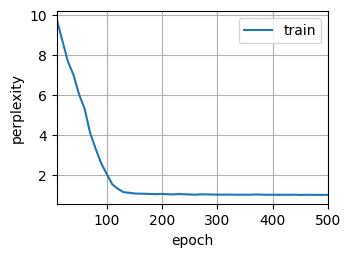

In [16]:
import torch
from torch import nn
from src.utils import load_data_time_machine, train_ch8, try_gpu

batch_size_100, num_steps_100 = 32, 100
train_iter_100, vocab_100 = load_data_time_machine(
    batch_size_100, num_steps_100)

rnn_before = nn.RNN(28, 512)
net_before = RNNModel_Embedding(rnn_before, 28, 28).to(try_gpu())
train_ch8(net_before, train_iter_100, vocab_100, 1, 500,
              try_gpu())


以下使用 `torch` 编程（不分离隐状态，`retain_graph=True`）：


**为什么 torch/CPU 版本必然报错：** 上述 `train_ch8_no_detach` 从不分离隐状态（无 `state.detach_()`），并调用 `l.backward(retain_graph=True)` 保留计算图，于是上一批次中隐状态 `state` 携带的图被逐批累积；而每批结束后 `updater.step()`（`torch.optim.SGD`，lr=1）会对 `nn.RNN(28, 512)` 的参数做 inplace 更新，使图中记录的变量版本失效，下一次 `backward` 即抛出 `RuntimeError: one of the variables needed for gradient computation has been modified by an inplace operation`（版本 2 ≠ 期望版本 1）。这正是不截断 BPTT 的后果：计算图跨批次保留并与参数更新冲突。下方 `PyPTO` 版本的 `train_ch8_no_detach_pypto`（NPU 上运行）行为不同，可以正常跑通。


In [17]:
from src.utils import Accumulator, Timer, grad_clipping, predict_ch8, sgd, try_gpu
import math

def train_epoch_ch8_no_detach(net, train_iter, loss, updater, device,
                               use_random_iter):
    state, timer = None, Timer()
    metric = Accumulator(2)
    for X, Y in train_iter:
        if state is None or use_random_iter:
            state = net.begin_state(batch_size=X.shape[0], device=device)
        # 注意：不 detach 隐状态，梯度跨批次传播
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long())
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward(retain_graph=True)
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward(retain_graph=True)
            grad_clipping(net, 1)
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()

def train_ch8_no_detach(net, train_iter, vocab, lr, num_epochs, device,
                         use_random_iter=False):
    loss = nn.CrossEntropyLoss()
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: sgd(net.params, lr, batch_size)
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8_no_detach(
            net, train_iter, loss, updater, device, use_random_iter)
        if (epoch + 1) % 10 == 0: print(predict('time traveller'))
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict('time traveller'))

rnn_after = nn.RNN(28, 512)
net_after = RNNModel_Embedding(rnn_after, 28, 28).to(try_gpu())
train_ch8_no_detach(net_after, train_iter_100, vocab_100, 1, 500,
                     try_gpu())


RuntimeError: one of the variables needed for gradient computation has been modified by an inplace operation: [torch.FloatTensor [512, 512]], which is output 0 of AsStridedBackward0, is at version 2; expected version 1 instead. Hint: enable anomaly detection to find the operation that failed to compute its gradient, with torch.autograd.set_detect_anomaly(True).

使用 `PyPTO` 编程（num_steps=100 标准训练）：


困惑度 1.0, 83213.3 词元/秒 npu:0
time traveller for so it will be convenient to speak of himwas e
travelleryou can show black is white by argument said filby


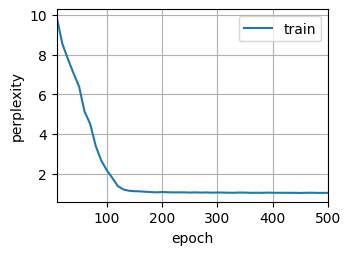

In [18]:
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOLinear, loss_fn
# 注：RNNModel_Embedding_PyPTO 在练习 8.5.2b 的 PyPTO cell 中定义，此处引用

batch_size_100, num_steps_100 = 32, 100
train_iter_100, vocab_100 = load_data_time_machine(
    batch_size_100, num_steps_100)

net_before_pypto = RNNModel_Embedding_PyPTO(len(vocab), 28, 512, device).to(device)
# JIT 预热
X_b, y_b = next(iter(train_iter_100))
s_b = net_before_pypto.begin_state(batch_size_100, device)
lb = loss_fn(net_before_pypto(X_b.to(device), s_b)[0],
            y_b.T.reshape(-1).to(device), 28)
lb.backward(); net_before_pypto.zero_grad()

train_ch8(net_before_pypto, train_iter_100, vocab_100, 1, 500,
          device, use_plot=True)


使用 `PyPTO` 编程（不分离隐状态，`retain_graph=True`）：


In [19]:
import math
from src.utils import predict_ch8, grad_clipping, Accumulator, Timer, sgd
# 注：RNNModel_Embedding_PyPTO 在练习 8.5.2b 的 PyPTO cell 中定义，此处引用
# 注：loss_fn 在 src/pypto_ops.py 中定义，练习 8.5.2a 的 PyPTO cell 中导入，此处引用

def train_epoch_ch8_no_detach_pypto(net, train_iter, loss_fn, updater, device):
    state, timer = None, Timer()
    metric = Accumulator(2)
    for X, Y in train_iter:
        if state is None:
            state = net.begin_state(batch_size=X.shape[0], device=device)
        # 不 detach：梯度跨批次传播
        y_t = Y.T.reshape(-1)
        X_d, y_t = X.to(device), y_t.to(device)
        y_hat, state = net(X_d, state)
        l = loss_fn(y_hat, y_t.long())
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward(retain_graph=True)
            grad_clipping(net, 1); updater.step()
        else:
            l.backward(retain_graph=True)
            grad_clipping(net, 1); updater(batch_size=1)
        metric.add(l * y_t.numel(), y_t.numel())
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()

def train_ch8_no_detach_pypto(net, train_iter, vocab, lr, num_epochs, device):
    loss = nn.CrossEntropyLoss()
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: sgd(net.params, lr, batch_size)
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8_no_detach_pypto(
            net, train_iter, loss, updater, device)
        if (epoch + 1) % 10 == 0:
            print(predict_ch8('time traveller', 50, net, vocab, device))
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict_ch8('time traveller', 50, net, vocab, device))

net_after_pypto = RNNModel_Embedding_PyPTO(len(vocab), 28, 512, device).to(device)
# JIT 预热
X_af, y_af = next(iter(train_iter_100))
s_af = net_after_pypto.begin_state(batch_size_100, device)
laf = loss_fn(net_after_pypto(X_af.to(device), s_af)[0],
             y_af.T.reshape(-1).to(device), 28)
laf.backward(); net_after_pypto.zero_grad()

train_ch8_no_detach_pypto(net_after_pypto, train_iter_100, vocab_100, 1, 500,
                           device)


time travellere the the the the the the the the the the the the 


time traveller the the the the the the the the the the the the t


time travellere the the the the the the the the the the the the 


time traveller sound the thing simensions of space the thing sin


time traveller chat in the rimentinn spaccenter spacely hav ghan


...

time traveller for so it will be convenient to speak of himwas e


time traveller with a slight accession ofcheerfulness really thi


time traveller for so it will be convenient to speak of himwas e


time travelleryou can show black is white by argument said filby


time travelleryou can show black is white by argument said filby
困惑度 1.0, 50854.3 词元/秒 npu:0
time travelleryou can show black is white by argument said filby


## 练习8.5.6

**题目：** 用 ReLU 替换本节中使用的激活函数，并重复本节中的实验。我们还需要梯度裁剪吗？为什么？

**解答：**
ReLU 在正半轴导数为 1、负半轴导数为 0，不会像 tanh 那样在饱和区出现梯度消失。Datawhale 实验表明从零实现的 ReLU RNN 即使不裁剪梯度也能稳定训练（困惑度 1.3），因为 tanh 的饱和特性才是梯度消失/爆炸的根源，ReLU 不会饱和。

注意：为公平比较，本次实验代码仍使用 train_ch8 内置的梯度裁剪，与 Datawhale 参考答案一致。ReLU“理论上”不需要梯度裁剪，但保留裁剪可作为标准训练流程的安全措施，防止数值不稳定。


以下使用 `torch` 编程：



困惑度 1.0, 25715.8 词元/秒 cpu
time traveller with a slight accession ofcheerfulness really thi
travelleryou can show black is white by argument said filby


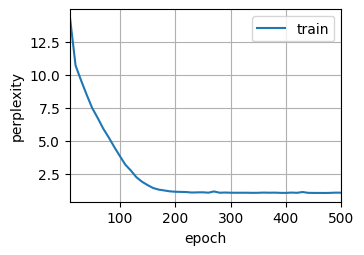

In [20]:
import torch
from torch import nn
from torch.nn import functional as F
from src.utils import load_data_time_machine, train_ch8, try_gpu

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size
    def normal(shape): return torch.randn(size=shape, device=device) * 0.01
    W_xh = normal((num_inputs, num_hiddens))
    W_hh = normal((num_hiddens, num_hiddens))
    b_h = torch.zeros(num_hiddens, device=device)
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for p in params: p.requires_grad_(True)
    return params

def init_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),)

def rnn_relu(inputs, state, params):
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state; outputs = []
    for X in inputs:
        H = torch.relu(torch.mm(X, W_xh) + torch.mm(H, W_hh) + b_h)
        Y = torch.mm(H, W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

class RNNModelScratch:
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params_fn, init_state_fn, forward_fn):
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.params = get_params_fn(vocab_size, num_hiddens, device)
        self.init_state = init_state_fn
        self.forward_fn = forward_fn
    def __call__(self, X, state):
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)
    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)

num_epochs, lr = 500, 1
net_relu = RNNModelScratch(len(vocab), 512, try_gpu(),
                            get_params, init_state, rnn_relu)
train_ch8(net_relu, train_iter, vocab, lr, num_epochs, try_gpu())


使用 `PyPTO` 编程：


困惑度 1.0, 11850.7 词元/秒 npu:0
time travelleryou can show black is white by argument said filby


travelleryou can show black is white by argument said filby


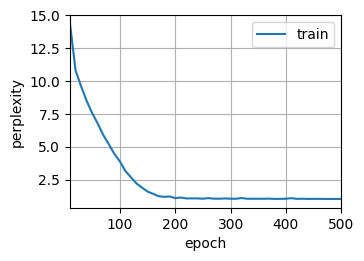

In [21]:
from src.utils import load_data_time_machine, train_ch8
from src.pypto_ops import PyPTOMatmul, PyPTOBiasAdd, PyPTOAdd, \
    PyPTOReLUOp, loss_fn

batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

def get_params_pypto(vocab_size, num_hiddens, device):
    def normal(shape): return torch.randn(size=shape, device=device) * 0.01
    w = [normal((vocab_size, num_hiddens)), normal((num_hiddens, num_hiddens)),
         torch.zeros(num_hiddens, device=device),
         normal((num_hiddens, vocab_size)), torch.zeros(vocab_size, device=device)]
    for p in w: p.requires_grad_(True)
    return w

def rnn_pypto_relu(inputs, state, params):
    W_xh, W_hh, b_h, W_hq, b_q = params
    (H,), outputs = state, []
    for X in inputs:
        XW = PyPTOMatmul.apply(X, W_xh)
        HW = PyPTOMatmul.apply(H, W_hh)
        H = PyPTOReLUOp.apply(
            PyPTOBiasAdd.apply(PyPTOAdd.apply(XW, HW), b_h))
        Y = PyPTOBiasAdd.apply(PyPTOMatmul.apply(H, W_hq), b_q)
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

class PyPTORNNModelScratch:
    def __init__(self, vocab_size, num_hiddens, device,
                 get_params_fn, init_state_fn, forward_fn):
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        self.device = device
        self.params = get_params_fn(vocab_size, num_hiddens, device)
        self.init_state = init_state_fn
        self.forward_fn = forward_fn
    def __call__(self, X, state):
        X_oh = F.one_hot(X.T, self.vocab_size).float()
        return self.forward_fn(X_oh, state, self.params)
    def begin_state(self, batch_size, device=None):
        d = device or self.device
        return self.init_state(batch_size, self.num_hiddens, d)

net_relu_pypto = PyPTORNNModelScratch(len(vocab), 512, device,
    get_params_pypto,
    lambda b, h, d: (torch.zeros((b, h), device=d),),
    rnn_pypto_relu)
# JIT 预热
X_r, y_r = next(iter(train_iter))
s_r = net_relu_pypto.begin_state(batch_size, device)
lr = loss_fn(net_relu_pypto(X_r.to(device), s_r)[0],
             y_r.T.reshape(-1).to(device), len(vocab))
lr.backward()

train_ch8(net_relu_pypto, train_iter, vocab, 1.0, 500, device, use_plot=True)


---
## 参考答案来源
参考答案和 PyTorch 代码实现来源：[https://datawhalechina.github.io/d2l-ai-solutions-manual/#/](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/)

